<a href="https://colab.research.google.com/github/MikeLuvsCake/ote-retracement-backtest/blob/main/OTE_Backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Backtest: OTE Retracement Zone (4H, 5 years)

This notebook tests the **trade logic** of my TradingView indicator *OTE Retracement Zone* on 5 years of 4-hour data for NQ, S&P 500, gold (XAUUSD) and EURUSD.

**The setup (the indicator's default filters):**
- Swings come from pivots with an 18-bar lookback (the indicator's auto setting for 4H), including the *provisional* (unconfirmed) swing anchor.
- A setup is live only when every filter passes: break of structure, swing age ≤ 4 × 18 bars, displacement ≥ 0.20 ATR per bar, the swing origin not yet taken out, and the zone not already "spent" by a close beyond 78.6%.
- **Stop:** 105% (5% of the leg beyond the swing origin). **Target:** 0%, the end of the impulse leg.

**Three entry modes are compared:**

| Mode | Entry |
|---|---|
| `0.618 only` | one limit order at the 61.8% level |
| `0.786 only` | one limit order at the 78.6% level |
| `split .618/.786` | half the position at 61.8%, half at 78.6% |

**What is *not* tested:** the support/resistance map, the higher-timeframe zone and the bias filter (the last two are off by default anyway).

**Rules that keep the test honest:**
- Only information up to a bar's close decides what happens on the next bar (no look-ahead; checked in section 10).
- On any bar where an order fills, only the stop can be hit on that bar. If one bar touches both the stop and the target, the stop is assumed to hit first.
- Gaps through a level fill at the open, not at the level.
- Round-trip trading costs are subtracted from every trade. One position at a time per market.

Results are in **R**: profit or loss divided by the amount risked. −1R is a full stop-out. In split mode, 1R is the loss if *both* halves fill and get stopped.

**To run:** `Runtime → Run all`. Downloading 5 years of data takes a few minutes.

In [25]:
# Setup
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
!pip -q install yfinance dukascopy-python
import yfinance as yf
import dukascopy_python as dk

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.8,
                     "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
                     "xtick.color": "#52514e", "ytick.color": "#52514e",
                     "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb"})
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # blue, orange, aqua, yellow

## 1. The engine
A bar-by-bar Python port of the indicator's `f_oteCore()` function, plus the trade simulator. Variables mirror the Pine Script names.

In [26]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Default settings, copied from the indicator's inputs
# ---------------------------------------------------------------------------
DEFAULTS = dict(
    pivot_len=18,      # auto lookback for a 4H chart (2h-4h -> 18)
    use_prov=True,     # anchor the zone to the unconfirmed swing
    prov_pull=20.0,    # pullback (% of leg) before an unconfirmed swing counts
    zone_lo=50.0,      # zone min %
    zone_hi=78.6,      # zone max %
    entry_pct=61.8,    # entry level for R:R
    stop_pad=5.0,      # stop beyond the 100% anchor, % of leg
    target_pct=0.0,    # target, same scale (0 = prior extreme, -27.2 = 1.272 ext)
    age_mult=4,        # max swing age, x pivot lookback
    min_disp=0.20,     # min displacement, net ATR per bar
    use_bos=True,      # require break of structure
    spent_mode="Deep exit only",
    min_swing_atr=0.0,
    side="Both",       # "Both", "Buy Only", "Sell Only"
)


def atr_rma(h, l, c, n=14):
    """ta.atr: Wilder (RMA) average of true range."""
    pc = np.r_[np.nan, c[:-1]]
    tr = np.fmax(h - l, np.fmax(np.abs(h - pc), np.abs(l - pc)))
    tr[0] = h[0] - l[0]
    out = np.full(len(c), np.nan)
    if len(c) < n:
        return out
    out[n - 1] = tr[:n].mean()
    a = 1.0 / n
    for i in range(n, len(c)):
        out[i] = a * tr[i] + (1 - a) * out[i - 1]
    return out


def compute_setups(df, **kw):
    """Bar-by-bar port of f_oteCore(). Every value at bar i uses bars <= i only.

    Returns a DataFrame with, per bar: dir (+1 buy / -1 sell / 0 none), ok (the
    setup passes every filter at this bar's close), eff_hi, eff_lo.
    """
    p = {**DEFAULTS, **kw}
    L = p["pivot_len"]
    zlo, zhi = min(p["zone_lo"], p["zone_hi"]), max(p["zone_lo"], p["zone_hi"])
    h, l, c = df["High"].to_numpy(float), df["Low"].to_numpy(float), df["Close"].to_numpy(float)
    n = len(c)
    atr = atr_rma(h, l, c, 14)

    out_dir = np.zeros(n, int)
    out_ok = np.zeros(n, bool)
    out_hi = np.full(n, np.nan)
    out_lo = np.full(n, np.nan)

    nan = np.nan
    lastHi = lastLo = prevHi = prevLo = nan
    lastHiBar = lastLoBar = None
    maxHiSinceLo = minLoSinceHi = nan
    maxHiBar = minLoBar = None
    loSinceMaxHi = hiSinceMinLo = nan
    zoneTouched = zoneBroken = zoneBounced = False
    prevEffHiBar = prevEffLoBar = None

    def isnan(x):
        return x is None or (isinstance(x, float) and np.isnan(x))

    for i in range(n):
        # ---- confirmed pivots (the bar printed L bars ago) -------------------
        pHi = pLo = nan
        if i >= 2 * L:
            pb = i - L
            if h[pb] > h[pb - L:pb].max() and h[pb] >= h[pb + 1:i + 1].max():
                pHi = h[pb]
            if l[pb] < l[pb - L:pb].min() and l[pb] <= l[pb + 1:i + 1].min():
                pLo = l[pb]

        # extremes over the pivot bar plus every bar since it confirmed
        s = max(0, i - L)
        seg_h, seg_l = h[s:i + 1], l[s:i + 1]
        # highestbars: offset back to the extreme (most recent on ties)
        hiBack = int(np.argmax(seg_h[::-1]))
        loBack = int(np.argmin(seg_l[::-1]))
        hiSincePivotBar = seg_h.max()
        loSincePivotBar = seg_l.min()
        loAfterHi = l[i - hiBack:i + 1].min()
        hiAfterLo = h[i - loBack:i + 1].max()

        if not np.isnan(pHi):
            prevHi, lastHi, lastHiBar = lastHi, pHi, i - L
        if not np.isnan(pLo):
            prevLo, lastLo, lastLoBar = lastLo, pLo, i - L

        if not np.isnan(pLo):
            maxHiSinceLo, maxHiBar, loSinceMaxHi = hiSincePivotBar, i - hiBack, loAfterHi
        elif not np.isnan(maxHiSinceLo):
            if h[i] > maxHiSinceLo:
                maxHiSinceLo, maxHiBar, loSinceMaxHi = h[i], i, l[i]
            else:
                loSinceMaxHi = min(l[i] if np.isnan(loSinceMaxHi) else loSinceMaxHi, l[i])

        if not np.isnan(pHi):
            minLoSinceHi, minLoBar, hiSinceMinLo = loSincePivotBar, i - loBack, hiAfterLo
        elif not np.isnan(minLoSinceHi):
            if l[i] < minLoSinceHi:
                minLoSinceHi, minLoBar, hiSinceMinLo = l[i], i, h[i]
            else:
                hiSinceMinLo = max(h[i] if np.isnan(hiSinceMinLo) else hiSinceMinLo, h[i])

        # ---- the unconfirmed leg --------------------------------------------
        provBullRange = nan if (np.isnan(lastLo) or np.isnan(maxHiSinceLo)) else maxHiSinceLo - lastLo
        provBearRange = nan if (np.isnan(lastHi) or np.isnan(minLoSinceHi)) else lastHi - minLoSinceHi
        bullSet = lastHiBar is not None and lastLoBar is not None and lastHiBar > lastLoBar
        bearSet = lastHiBar is not None and lastLoBar is not None and lastLoBar > lastHiBar
        provBull = (p["use_prov"] and not np.isnan(provBullRange) and provBullRange > 0 and
                    maxHiBar is not None and lastLoBar is not None and maxHiBar > lastLoBar and
                    (bullSet or (maxHiSinceLo - c[i]) >= p["prov_pull"] / 100 * provBullRange))
        provBear = (p["use_prov"] and not np.isnan(provBearRange) and provBearRange > 0 and
                    minLoBar is not None and lastHiBar is not None and minLoBar > lastHiBar and
                    (bearSet or (c[i] - minLoSinceHi) >= p["prov_pull"] / 100 * provBearRange))
        mid = (zlo + zhi) / 200.0
        bullMid = nan if (np.isnan(maxHiSinceLo) or np.isnan(lastLo)) else maxHiSinceLo - (maxHiSinceLo - lastLo) * mid
        bearMid = nan if (np.isnan(minLoSinceHi) or np.isnan(lastHi)) else minLoSinceHi + (lastHi - minLoSinceHi) * mid
        nearBull = True if (np.isnan(bullMid) or np.isnan(bearMid)) else abs(c[i] - bullMid) <= abs(c[i] - bearMid)
        takeBull = provBull and (not provBear or nearBull)
        takeBear = provBear and not takeBull

        effHi = maxHiSinceLo if takeBull else lastHi
        effHiBar = maxHiBar if takeBull else lastHiBar
        effLo = minLoSinceHi if takeBear else lastLo
        effLoBar = minLoBar if takeBear else lastLoBar

        swingRange = nan if (np.isnan(effHi) or np.isnan(effLo)) else effHi - effLo
        validSwing = (not np.isnan(swingRange) and swingRange > 0 and
                      effHiBar is not None and effLoBar is not None)

        legAtr = atr[i]
        if validSwing:
            legEnd = max(effHiBar, effLoBar)
            back = max(0, min(i - legEnd, 490))
            if not np.isnan(atr[i - back]):
                legAtr = atr[i - back]
        bigEnough = validSwing and (p["min_swing_atr"] <= 0 or np.isnan(legAtr) or swingRange >= p["min_swing_atr"] * legAtr)

        bull = validSwing and effHiBar > effLoBar
        bear = validSwing and effLoBar > effHiBar

        buyRefLo = loSinceMaxHi if takeBull else minLoSinceHi
        sellRefHi = hiSinceMinLo if takeBear else maxHiSinceLo
        buyAlive = bull and not np.isnan(buyRefLo) and buyRefLo > effLo
        sellAlive = bear and not np.isnan(sellRefHi) and sellRefHi < effHi

        fresh = validSwing and (i - max(effHiBar, effLoBar)) <= p["age_mult"] * L

        if effHiBar is None or lastHiBar is None or effHiBar > lastHiBar:
            bosRefHi = lastHi
        else:
            bosRefHi = prevHi
        if effLoBar is None or lastLoBar is None or effLoBar > lastLoBar:
            bosRefLo = lastLo
        else:
            bosRefLo = prevLo
        bosDown = not np.isnan(bosRefLo) and not np.isnan(effLo) and effLo < bosRefLo
        bosUp = not np.isnan(bosRefHi) and not np.isnan(effHi) and effHi > bosRefHi
        okStructBuy = (not p["use_bos"]) or bosUp
        okStructSell = (not p["use_bos"]) or bosDown

        if bull:
            rawR = (effHi - c[i]) / swingRange * 100
            rDeep = (effHi - l[i]) / swingRange * 100
            rShal = (effHi - h[i]) / swingRange * 100
        elif bear:
            rawR = (c[i] - effLo) / swingRange * 100
            rDeep = (h[i] - effLo) / swingRange * 100
            rShal = (l[i] - effLo) / swingRange * 100
        else:
            rawR = rDeep = rShal = nan
        # touch on wick, leave on close (the defaults)
        inBand = not np.isnan(rDeep) and rDeep >= zlo and rShal <= zhi
        pastTop = not np.isnan(rawR) and rawR > zhi
        pastBot = not np.isnan(rawR) and rawR < zlo

        anchorMoved = ((prevEffHiBar is not None and effHiBar != prevEffHiBar) or
                       (prevEffLoBar is not None and effLoBar != prevEffLoBar))
        newSwing = (not np.isnan(pHi)) or (not np.isnan(pLo)) or anchorMoved
        if newSwing:
            zoneTouched, zoneBroken, zoneBounced = inBand, False, False
        else:
            if inBand:
                zoneTouched = True
            if pastTop:
                zoneBroken = True
            if zoneTouched and pastBot:
                zoneBounced = True
        prevEffHiBar, prevEffLoBar = effHiBar, effLoBar

        mode = p["spent_mode"]
        spent = False if mode == "Never" else (zoneBroken if mode == "Deep exit only" else (zoneBroken or zoneBounced))

        sharp = True
        if p["min_disp"] > 0 and validSwing and not np.isnan(legAtr) and legAtr > 0:
            legBars = max(1, abs(effHiBar - effLoBar))
            sharp = (swingRange / legBars) / legAtr >= p["min_disp"]

        okBuy = buyAlive and bigEnough and fresh and okStructBuy and sharp and not spent
        okSell = sellAlive and bigEnough and fresh and okStructSell and sharp and not spent
        if p["side"] == "Buy Only":
            okSell = False
        if p["side"] == "Sell Only":
            okBuy = False

        out_dir[i] = 1 if bull else (-1 if bear else 0)
        out_ok[i] = okBuy or okSell
        out_hi[i], out_lo[i] = effHi, effLo

    return pd.DataFrame({"dir": out_dir, "ok": out_ok, "eff_hi": out_hi, "eff_lo": out_lo}, index=df.index)


# Entry modes. Each is a list of (retracement level %, share of the position).
ENTRY_MODES = {
    "0.618 only":     [(61.8, 1.0)],
    "0.786 only":     [(78.6, 1.0)],
    "split .618/.786": [(61.8, 0.5), (78.6, 0.5)],
}


def level_price(direction, hi, lo, pct):
    """Price of a retracement level. Buy: 0% at the high, 100% at the low.
    Sell: 0% at the low, 100% at the high."""
    rng = hi - lo
    return hi - rng * pct / 100 if direction == 1 else lo + rng * pct / 100


def simulate_position(o, h, l, c, j, d, levels_w, stop, target):
    """Run one position from its first fill on bar j.

    levels_w: list of (price, weight), shallowest first. Orders still unfilled
    stay live until the position closes.
    Conservative rules: on any bar where an order fills, only the stop can be
    hit on that bar (we can't know if the target came before or after the fill).
    If one bar spans both stop and target, the stop is assumed to hit first.
    Gaps fill at the open, not at the level.
    Returns (exit_bar, exit_price, reason, fills) with fills = [(price, weight)].
    """
    n = len(c)
    fills, pending = [], list(levels_w)

    def try_fill(k):
        nonlocal pending
        filled_now, keep = False, []
        for px, w in pending:
            hit = (l[k] <= px) if d == 1 else (h[k] >= px)
            if hit:
                fills.append((min(o[k], px) if d == 1 else max(o[k], px), w))
                filled_now = True
            else:
                keep.append((px, w))
        pending = keep
        return filled_now

    try_fill(j)   # the first fill bar
    if (d == 1 and l[j] <= stop) or (d == -1 and h[j] >= stop):
        return j, stop, "stop", fills
    for k in range(j + 1, n):
        if (d == 1 and o[k] <= stop) or (d == -1 and o[k] >= stop):
            return k, o[k], "stop", fills
        if (d == 1 and o[k] >= target) or (d == -1 and o[k] <= target):
            return k, o[k], "target", fills
        if try_fill(k):
            if (d == 1 and l[k] <= stop) or (d == -1 and h[k] >= stop):
                return k, stop, "stop", fills
            continue
        if (d == 1 and l[k] <= stop) or (d == -1 and h[k] >= stop):
            return k, stop, "stop", fills
        if (d == 1 and h[k] >= target) or (d == -1 and l[k] <= target):
            return k, target, "target", fills
    return n - 1, c[n - 1], "open at end", fills


def backtest(df, cost=0.0, setups=None, entry_mode="0.618 only", entries=None, **kw):
    """Trade the indicator's setups, one position at a time.

    While a setup passes every filter at the close of bar i, limit orders sit at
    the entry level(s) for bar i+1, re-priced every bar (the provisional anchor
    can move). The position opens when the first of them fills.

    R is measured against the FULL planned risk: if every entry fills and the
    stop is hit, that is -1R. In split mode, a trade where only the 0.618 half
    filled risks less than 1R, which is the honest way to count it.
    `cost` is the round-trip cost in price units for a full position.
    """
    p = {**DEFAULTS, **kw}
    entries = entries or ENTRY_MODES[entry_mode]
    if setups is None:
        setups = compute_setups(df, **kw)
    o, h, l, c = (df[k].to_numpy(float) for k in ("Open", "High", "Low", "Close"))
    dd, ok, eh, el = (setups[k].to_numpy() for k in ("dir", "ok", "eff_hi", "eff_lo"))
    n = len(c)
    trades = []
    i = 0
    while i < n - 1:
        if not ok[i]:
            i += 1
            continue
        d = int(dd[i])
        stop = level_price(d, eh[i], el[i], 100 + p["stop_pad"])
        target = level_price(d, eh[i], el[i], p["target_pct"])
        lv = sorted([(level_price(d, eh[i], el[i], pct), w) for pct, w in entries],
                    key=lambda x: -x[0] * d)   # shallowest first
        j = i + 1
        first_hit = (l[j] <= lv[0][0]) if d == 1 else (h[j] >= lv[0][0])
        gap_through_stop = (o[j] <= stop) if d == 1 else (o[j] >= stop)
        if not first_hit or gap_through_stop:
            i += 1
            continue
        k, exit_px, reason, fills = simulate_position(o, h, l, c, j, d, lv, stop, target)
        planned_risk = sum(w * abs(px - stop) for px, w in lv)
        w_filled = sum(w for _, w in fills)
        avg_fill = sum(px * w for px, w in fills) / w_filled
        pnl = sum(w * d * (exit_px - px) for px, w in fills) - cost * w_filled
        trades.append(dict(
            signal_time=df.index[i], entry_time=df.index[j], exit_time=df.index[k],
            direction="long" if d == 1 else "short",
            entry=avg_fill, stop=stop, target=target, exit=exit_px, reason=reason,
            filled_share=w_filled, risk=planned_risk, pnl=pnl, R=pnl / planned_risk,
            bars_held=k - j, reward_risk=abs(target - avg_fill) / abs(avg_fill - stop),
        ))
        i = k + 1
    return pd.DataFrame(trades)


def random_baseline(df, trades, cost=0.0, n_runs=300, seed=0):
    """Same trades, random timing. For every real trade, pick a random bar and
    take the same direction with the same stop and target distances (as a share
    of price) and the same position size. Returns the average R of each run.
    """
    rng = np.random.default_rng(seed)
    o, h, l, c = (df[k].to_numpy(float) for k in ("Open", "High", "Low", "Close"))
    n = len(c)
    if len(trades) == 0:
        return np.array([])
    dirs = np.where(trades["direction"] == "long", 1, -1)
    e = trades["entry"].to_numpy()
    stop_f = (trades["entry"] - trades["stop"]).abs().to_numpy() / e
    tgt_f = (trades["target"] - trades["entry"]).abs().to_numpy() / e
    share = trades["filled_share"].to_numpy()
    # planned risk relative to the risk actually taken, so R is on the same scale
    scale = trades["risk"].to_numpy() / ((trades["entry"] - trades["stop"]).abs().to_numpy() * share)
    res = []
    for _ in range(n_runs):
        rs = []
        for t in range(len(trades)):
            j = int(rng.integers(50, n - 2))
            px, d = o[j], dirs[t]
            stop = px - d * stop_f[t] * px
            tgt = px + d * tgt_f[t] * px
            k, x, _, _ = simulate_position(o, h, l, c, j, d, [(px, 1.0)], stop, tgt)
            rs.append((share[t] * (d * (x - px) - cost)) / (share[t] * abs(px - stop) * scale[t]))
        res.append(np.mean(rs))
    return np.array(res)


def summarize(trades):
    if len(trades) == 0:
        return dict(trades=0)
    R = trades["R"].to_numpy()
    eq = np.cumsum(R)
    dd = (eq - np.maximum.accumulate(np.r_[0, eq])[1:]).min()
    wins, losses = R[R > 0], R[R <= 0]
    se = R.std(ddof=1) / np.sqrt(len(R)) if len(R) > 1 else np.nan
    return dict(
        trades=len(R),
        win_rate=len(wins) / len(R),
        breakeven_win_rate=1 / (1 + trades["reward_risk"].mean()),
        avg_R=R.mean(),
        t_stat=R.mean() / se if se and se > 0 else np.nan,
        total_R=R.sum(),
        profit_factor=wins.sum() / -losses.sum() if losses.sum() < 0 else np.inf,
        max_drawdown_R=dd,
        avg_bars_held=trades["bars_held"].mean(),
    )

## 2. Settings

**Data:** 4H bars are built from Dukascopy's free hourly data (spot prices, the same kind of instrument you see on TradingView as NAS100 / SPX500 / XAUUSD / EURUSD). If Dukascopy can't be reached, the notebook falls back to Yahoo Finance, which only has about 2 years of hourly data, and says so.

**Costs** are round-trip (entry + exit), in price units, and deliberately a bit pessimistic.

The `range` column is a sanity check: if the downloaded prices fall outside it, the wrong instrument came back and the notebook stops.

In [27]:
YEARS = 5

MARKETS = {
    # name:      Dukascopy symbols to try,              Yahoo fallback, cost,    plausible price range
    "NQ":      dict(duka=["E_NQ-100", "USATECH.IDX/USD"],   yahoo="NQ=F",     cost=1.00,    range=(5000, 40000)),
    "S&P 500": dict(duka=["E_SandP-500", "USA500.IDX/USD"], yahoo="ES=F",     cost=0.50,    range=(2000, 10000)),
    "Gold":    dict(duka=["XAU/USD"],                       yahoo="GC=F",     cost=0.40,    range=(1000, 6000)),
    "EURUSD":  dict(duka=["EUR/USD"],                       yahoo="EURUSD=X", cost=0.00015, range=(0.8, 1.4)),
}
CSV_FILES = {}           # optional: {"EURUSD": "/content/eurusd_4h.csv"} with columns time, open, high, low, close
PARAMS = dict(DEFAULTS)  # the indicator's defaults, from the engine cell
MODES = list(ENTRY_MODES)
IN_SAMPLE_SHARE = 0.70   # first 70% of each history = in-sample, last 30% = out-of-sample
cost = lambda m: MARKETS[m]["cost"]
PARAMS

{'pivot_len': 18,
 'use_prov': True,
 'prov_pull': 20.0,
 'zone_lo': 50.0,
 'zone_hi': 78.6,
 'entry_pct': 61.8,
 'stop_pad': 5.0,
 'target_pct': 0.0,
 'age_mult': 4,
 'min_disp': 0.2,
 'use_bos': True,
 'spent_mode': 'Deep exit only',
 'min_swing_atr': 0.0,
 'side': 'Both'}

## 3. Download the data

In [28]:
def _clean(df):
    df = df[["Open", "High", "Low", "Close"]].dropna()
    df = df[(df["High"] >= df["Low"]) & (df["Close"] > 0)]
    return df[df["High"] > df["Low"]]          # drops flat placeholder bars (weekends, holidays)

def _to_4h(df):
    return _clean(df.resample("4h").agg({"Open": "first", "High": "max", "Low": "min", "Close": "last"}))

def _synthetic(n, seed, freq, start_px):
    # Only used to test this notebook offline. Random walk: no edge by construction.
    r = np.random.default_rng(seed)
    c = start_px * np.exp(np.cumsum(r.standard_t(4, n) * 0.003))
    o = np.r_[start_px, c[:-1]]
    h = np.maximum(o, c) * np.exp(np.abs(r.normal(0, 0.002, n)))
    l = np.minimum(o, c) * np.exp(-np.abs(r.normal(0, 0.002, n)))
    idx = pd.date_range("2005-01-03", periods=n, freq=freq, tz="UTC")
    return pd.DataFrame(dict(Open=o, High=h, Low=l, Close=c), index=idx)

SYNTHETIC = os.environ.get("OTE_SYNTHETIC") == "1"

def _check(name, df, source):
    lo, hi = MARKETS[name]["range"]
    med = df["Close"].median()
    if not (lo <= med <= hi):
        raise ValueError(f"{name} from {source}: median price {med:,.2f} is outside {lo}-{hi}. Wrong instrument?")
    return df

def load_4h(name):
    cfg = MARKETS[name]
    if SYNTHETIC:
        return _synthetic(7500, list(MARKETS).index(name), "4h", np.mean(cfg["range"])), "synthetic"
    if name in CSV_FILES:
        df = pd.read_csv(CSV_FILES[name]); df.columns = [c.lower() for c in df.columns]
        df["time"] = pd.to_datetime(df["time"], utc=True)
        return _check(name, _clean(df.set_index("time").rename(columns=str.title)), "CSV"), "CSV"
    end = datetime.now(timezone.utc).replace(tzinfo=None)
    start = end - timedelta(days=int(365.25 * YEARS))
    for sym in cfg["duka"]:
        try:
            raw = dk.fetch(sym, dk.INTERVAL_HOUR_1, dk.OFFER_SIDE_BID, start, end)
            if len(raw) > 1000:
                raw = raw.rename(columns=str.title)
                return _check(name, _to_4h(raw), f"Dukascopy {sym}"), f"Dukascopy {sym}"
        except Exception as e:
            print(f"  Dukascopy {sym} failed: {type(e).__name__}: {str(e)[:120]}")
    print(f"  ⚠️ {name}: falling back to Yahoo Finance (only ~2 years of hourly data).")
    raw = yf.Ticker(cfg["yahoo"]).history(period="730d", interval="1h", auto_adjust=False)
    if raw.empty:
        raise RuntimeError(f"No data for {name} from Dukascopy or Yahoo. Try running this cell again.")
    raw.index = raw.index.tz_convert("UTC")
    return _check(name, _to_4h(raw), "Yahoo"), "Yahoo (2y)"

DATA_4H, SOURCE = {}, {}
for m in MARKETS:
    print(f"Downloading {m} ...")
    DATA_4H[m], SOURCE[m] = load_4h(m)
pd.DataFrame({m: {"source": SOURCE[m], "4H bars": len(d), "from": d.index[0].date(), "to": d.index[-1].date()}
              for m, d in DATA_4H.items()}).T

INFO:DUKASCRIPT:current timestamp :2026-09-25T20:00:00


INFO:DUKASCRIPT:current timestamp :2026-09-25T20:00:00


INFO:DUKASCRIPT:current timestamp :2026-09-25T20:00:00


INFO:DUKASCRIPT:current timestamp :2026-07-20T16:00:00
INFO:DUKASCRIPT:current timestamp :2026-09-25T20:00:00


,source,4H bars,from,to
NQ,Dukascopy E_NQ-100,7990,2021-09-27,2026-09-25
S&P 500,Dukascopy E_SandP-500,7991,2021-09-27,2026-09-25
Gold,Dukascopy XAU/USD,7995,2021-09-27,2026-09-25
EURUSD,Dukascopy EUR/USD,8060,2021-09-27,2026-09-25


## 4. Compare the three entry modes

Testing three variants and picking whichever looks best is a trap: with enough variants, one will look good by luck. So the rule here is:

1. **Choose the mode using the in-sample period only** (the first 70% of the data).
2. **Judge it on the out-of-sample period** (the last 30%), which played no part in the choice.

The out-of-sample columns are the honest result.

In [29]:
SETUPS_4H = {m: compute_setups(df, **PARAMS) for m, df in DATA_4H.items()}

def run(data, setups, params, mode):
    out = []
    for m, df in data.items():
        t = backtest(df, cost=cost(m), setups=setups[m], entry_mode=mode, **params)
        if len(t):
            split_time = df.index[int(len(df) * IN_SAMPLE_SHARE)]
            t["sample"] = np.where(t["entry_time"] < split_time, "in-sample", "out-of-sample")
            t["market"] = m
            t["mode"] = mode
            out.append(t)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

TRADES = {mode: run(DATA_4H, SETUPS_4H, PARAMS, mode) for mode in MODES}

cols = ["trades", "win_rate", "breakeven_win_rate", "avg_R", "t_stat", "total_R", "max_drawdown_R"]
def mode_table(trades_by_mode):
    rows = {}
    for mode, t in trades_by_mode.items():
        for s in ["in-sample", "out-of-sample"]:
            rows[(mode, s)] = summarize(t[t["sample"] == s]) if len(t) else {}
    return pd.DataFrame(rows).T.reindex(columns=cols)

MODE_TABLE = mode_table(TRADES)
display(MODE_TABLE)

in_sample_avg = {mode: MODE_TABLE.loc[(mode, "in-sample"), "avg_R"] for mode in MODES}
CHOSEN = max(in_sample_avg, key=lambda k: -np.inf if pd.isna(in_sample_avg[k]) else in_sample_avg[k])
oos = MODE_TABLE.loc[(CHOSEN, "out-of-sample")]
print(f"Chosen on in-sample data: {CHOSEN}  (in-sample avg R {in_sample_avg[CHOSEN]:+.3f})")
print(f"Its out-of-sample result: {int(oos['trades'])} trades, avg R {oos['avg_R']:+.3f}, t-stat {oos['t_stat']:+.2f}")

trades  win_rate  breakeven_win_rate  avg_R  t_stat  total_R  max_drawdown_R
0.618 only      in-sample     155.000     0.368               0.371 -0.040  -0.414   -6.169         -22.431
                out-of-sample  59.000     0.441               0.375  0.128   0.802    7.572          -9.129
0.786 only      in-sample     126.000     0.270               0.240  0.088   0.553   11.120         -18.291
                out-of-sample  46.000     0.283               0.248  0.118   0.439    5.430         -17.286
split .618/.786 in-sample     155.000     0.368               0.319 -0.001  -0.011   -0.178         -22.340
                out-of-sample  59.000     0.441               0.328  0.095   0.570    5.618         -11.203

Chosen on in-sample data: 0.786 only  (in-sample avg R +0.088)
Its out-of-sample result: 46 trades, avg R +0.118, t-stat +0.44


**How to read this**
- `win_rate` vs `breakeven_win_rate`: the win rate you need just to break even at that reward-to-risk. At 0.618 it's about 41%; at 0.786 the stop is much closer, so it's only about 25%. The gap between the two is the edge.
- `avg_R` is the expectancy per trade. `t_stat` says whether it's distinguishable from zero: roughly, |t| < 2 means **it could easily be luck**.
- A real edge shows up in **both** in-sample and out-of-sample.

## 5. The chosen mode, market by market

,trades,win_rate,breakeven_win_rate,avg_R,t_stat,total_R,max_drawdown_R,profit_factor,avg_bars_held
NQ,44.000,0.250,0.250,-0.006,-0.024,-0.279,-14.033,0.992,21.227
S&P 500,51.000,0.333,0.232,0.380,1.398,19.371,-9.159,1.587,19.039
Gold,35.000,0.314,0.250,0.234,0.739,8.174,-8.011,1.336,31.286
EURUSD,42.000,0.190,0.240,-0.255,-1.042,-10.716,-22.501,0.689,19.405
ALL MARKETS,172.000,0.273,0.242,0.096,0.703,16.550,-22.501,1.133,22.180


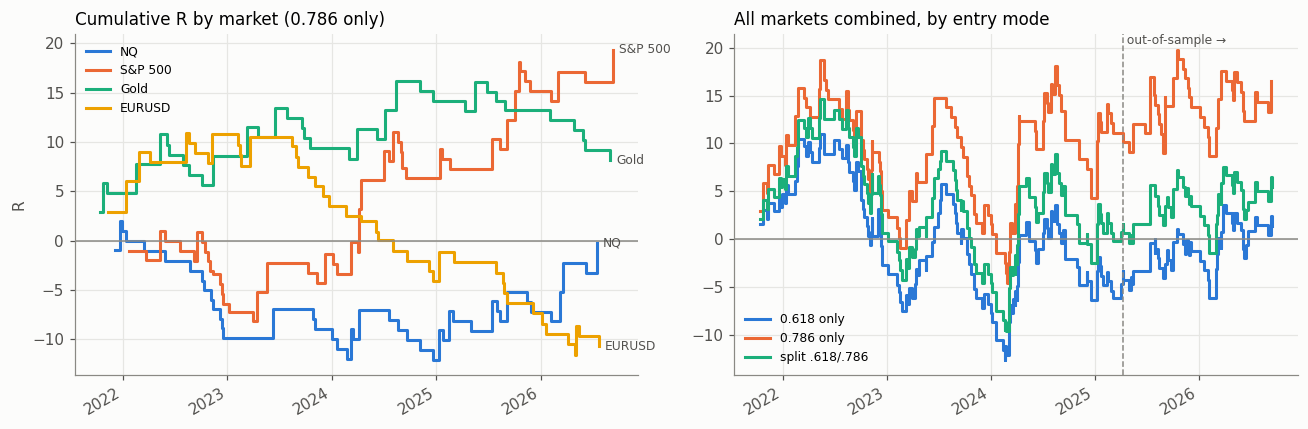

In [30]:
T = TRADES[CHOSEN]
rows = {m: summarize(T[T["market"] == m]) for m in MARKETS}
rows["ALL MARKETS"] = summarize(T)
display(pd.DataFrame(rows).T.reindex(columns=cols + ["profit_factor", "avg_bars_held"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
for m, col in zip(MARKETS, COLORS):
    t = T[T["market"] == m].sort_values("exit_time")
    if len(t):
        eq = t["R"].cumsum()
        ax.plot(t["exit_time"], eq, color=col, lw=2, label=m, drawstyle="steps-post")
        ax.annotate(m, (t["exit_time"].iloc[-1], eq.iloc[-1]), xytext=(4, 0),
                    textcoords="offset points", color="#52514e", fontsize=8, va="center")
ax.axhline(0, color="#8a8984", lw=1)
ax.set_title(f"Cumulative R by market ({CHOSEN})", loc="left", fontsize=11)
ax.set_ylabel("R"); ax.legend(frameon=False, fontsize=8)

ax = axes[1]
for mode, col in zip(MODES, COLORS):
    a = TRADES[mode].sort_values("exit_time")
    if len(a):
        ax.plot(a["exit_time"], a["R"].cumsum(), color=col, lw=2, label=mode, drawstyle="steps-post")
split = T.loc[T["sample"] == "out-of-sample", "entry_time"]
if len(split):
    ax.axvline(split.min(), color="#8a8984", lw=1, ls="--")
    ax.text(split.min(), ax.get_ylim()[1], " out-of-sample →", color="#52514e", fontsize=8, va="top")
ax.axhline(0, color="#8a8984", lw=1)
ax.set_title("All markets combined, by entry mode", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 6. Is the entry timing doing anything? (random-timing baseline)

The stop and target shape alone produce a certain win rate whatever the entry. This takes **the chosen mode's trades, with the same direction, stop and target distances and size**, and places them at random bars instead, 300 times.

If the real result isn't above nearly all of the random ones, the indicator's timing isn't adding anything.

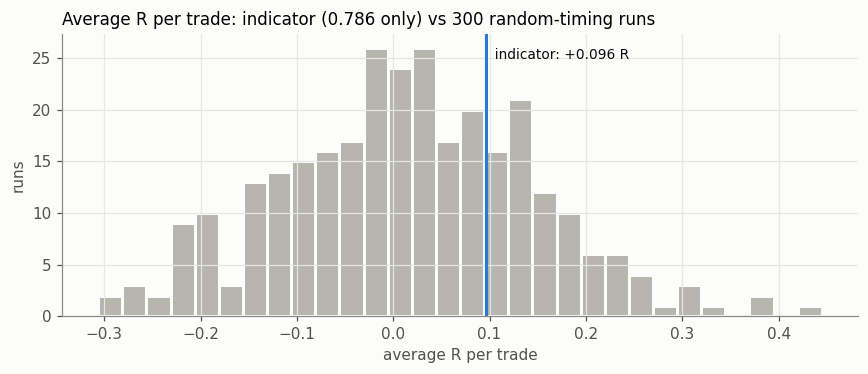

The indicator beat 72% of random-timing runs.
Rough guide: above 95% is evidence of real timing skill; 50-90% is indistinguishable from chance.


In [31]:
rand_sum, n_total = 0, 0
for m in MARKETS:
    t = T[T["market"] == m]
    if len(t):
        rand_sum = rand_sum + random_baseline(DATA_4H[m], t, cost=cost(m), n_runs=300, seed=1) * len(t)
        n_total += len(t)
rand_avg = rand_sum / n_total
real_avg = T["R"].mean()
pct = (rand_avg < real_avg).mean() * 100

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(rand_avg, bins=30, color="#b6b5ae", edgecolor="#fcfcfb", linewidth=2)
ax.axvline(real_avg, color=COLORS[0], lw=2)
ax.text(real_avg, ax.get_ylim()[1] * 0.95, f"  indicator: {real_avg:+.3f} R", color="#0b0b0b", fontsize=9, va="top")
ax.set_title(f"Average R per trade: indicator ({CHOSEN}) vs 300 random-timing runs", loc="left", fontsize=11)
ax.set_xlabel("average R per trade"); ax.set_ylabel("runs")
plt.tight_layout(); plt.show()
print(f"The indicator beat {pct:.0f}% of random-timing runs.")
print("Rough guide: above 95% is evidence of real timing skill; 50-90% is indistinguishable from chance.")

## 7. Versus buy-and-hold
The strategy risks **1% of the account per trade**, compounded, over exactly the same period as holding the market.

In [32]:
rows = {}
for m, df in DATA_4H.items():
    t = T[T["market"] == m]
    rows[m] = {"buy_and_hold": df["Close"].iloc[-1] / df["Close"].iloc[0] - 1,
               "strategy_1pct_risk": np.prod(1 + 0.01 * t["R"].to_numpy()) - 1 if len(t) else 0.0,
               "trades": len(t)}
pd.DataFrame(rows).T.style.format({"buy_and_hold": "{:+.1%}", "strategy_1pct_risk": "{:+.1%}", "trades": "{:.0f}"})

,buy_and_hold,strategy_1pct_risk,trades
NQ,+101.7%,-0.9%,44
S&P 500,+74.3%,+20.2%,51
Gold,+144.6%,+7.9%,35
EURUSD,-2.6%,-10.6%,42


The strategy is out of the market most of the time, so it also carries much less risk than holding. Check the drawdown column too, not just returns.

## 8. Robustness: does it only work with these exact settings?

Average R across all four markets, **in-sample only**, when the entry mode, target and displacement filter change. You want a broad area of similar results, not one lucky cell.

⚠️ Don't pick the best cell and call it the strategy. That's overfitting.

In [33]:
grid = []
for disp in [0.0, 0.20, 0.40]:
    p0 = {**PARAMS, "min_disp": disp}
    setups = {m: compute_setups(df, **p0) for m, df in DATA_4H.items()}
    for mode in MODES:
        for tgt in [0.0, -27.2]:
            t = run(DATA_4H, setups, {**p0, "target_pct": tgt}, mode)
            t = t[t["sample"] == "in-sample"] if len(t) else t
            grid.append({"min_disp": disp, "entry": mode, "target %": tgt, "avg_R": t["R"].mean() if len(t) else np.nan})
GRID = pd.DataFrame(grid)
GRID.pivot_table(index=["min_disp", "entry"], columns="target %", values="avg_R").style.format("{:+.3f}").background_gradient(cmap="RdBu", vmin=-0.5, vmax=0.5)

## 9. An even bigger sample: daily bars, 20+ years

The same logic on **daily** bars from Yahoo (lookback 20, the indicator's auto setting for 1D). It's a different timeframe, so it doesn't prove the 4H version, but a real edge in the idea should show up here too.

In [34]:
def load_1d(name):
    if SYNTHETIC:
        return _synthetic(5500, list(MARKETS).index(name) + 10, "B", np.mean(MARKETS[name]["range"]))
    raw = yf.Ticker(MARKETS[name]["yahoo"]).history(period="max", interval="1d", auto_adjust=False)
    return _clean(raw)

DATA_1D = {m: load_1d(m) for m in MARKETS}
P1D = {**PARAMS, "pivot_len": 20}
SETUPS_1D = {m: compute_setups(df, **P1D) for m, df in DATA_1D.items()}
TRADES_1D = {mode: run(DATA_1D, SETUPS_1D, P1D, mode) for mode in MODES}
print("History:", {m: f"{d.index[0].year}-{d.index[-1].year}" for m, d in DATA_1D.items()})
mode_table(TRADES_1D)

History: {'NQ': '2000-2026', 'S&P 500': '2000-2026', 'Gold': '2000-2026', 'EURUSD': '2003-2026'}


trades  win_rate  breakeven_win_rate  avg_R  t_stat  total_R  max_drawdown_R
0.618 only      in-sample      84.000     0.369               0.375 -0.055  -0.429   -4.654         -13.342
                out-of-sample  36.000     0.528               0.386  0.326   1.611   11.723          -2.844
0.786 only      in-sample      67.000     0.254               0.243  0.031   0.141    2.051         -10.996
                out-of-sample  28.000     0.429               0.245  0.726   1.922   20.327          -4.009
split .618/.786 in-sample      84.000     0.369               0.321 -0.025  -0.178   -2.111         -12.765
                out-of-sample  36.000     0.528               0.332  0.372   1.673   13.391          -2.956

## 10. Check that there's no look-ahead

Recomputes the setups on histories cut off at several points and checks every bar before the cut-off matches the full-history run. If the engine were peeking at future bars, they would differ.

In [35]:
m = list(DATA_4H)[0]; df = DATA_4H[m]; full = SETUPS_4H[m]
for frac in [0.4, 0.6, 0.8]:
    cut = int(len(df) * frac)
    part = compute_setups(df.iloc[:cut], **PARAMS)
    same = (full["ok"].iloc[:cut].values == part["ok"].values).all() and \
           np.allclose(full["eff_hi"].iloc[:cut].values, part["eff_hi"].values, equal_nan=True)
    print(f"{m}: history cut at {frac:.0%} -> identical signals: {same}")

NQ: history cut at 40% -> identical signals: True
NQ: history cut at 60% -> identical signals: True
NQ: history cut at 80% -> identical signals: True


## 11. Save the trade lists
In Colab, click the folder icon on the left sidebar and download these before closing the session.

In [36]:
pd.concat(TRADES.values(), ignore_index=True).to_csv("ote_trades_4h.csv", index=False)
pd.concat(TRADES_1D.values(), ignore_index=True).to_csv("ote_trades_1d.csv", index=False)
MODE_TABLE.to_csv("ote_summary_4h.csv")
print("Saved: ote_trades_4h.csv, ote_trades_1d.csv, ote_summary_4h.csv")
T[["market", "direction", "entry_time", "entry", "filled_share", "stop", "target", "exit_time", "exit", "reason", "R", "sample"]].tail(10)

Saved: ote_trades_4h.csv, ote_trades_1d.csv, ote_summary_4h.csv


,market,direction,entry_time,entry,filled_share,stop,target,exit_time,exit,reason,R,sample
162,EURUSD,long,2025-08-27 04:00:00+00:00,1.162,1.000,1.157,1.174,2025-08-27 08:00:00+00:00,1.157,stop,-1.036,out-of-sample
163,EURUSD,short,2025-08-29 12:00:00+00:00,1.171,1.000,1.175,1.157,2025-09-05 12:00:00+00:00,1.175,stop,-1.034,out-of-sample
164,EURUSD,short,2025-11-13 08:00:00+00:00,1.163,1.000,1.168,1.147,2025-12-04 08:00:00+00:00,1.168,stop,-1.028,out-of-sample
165,EURUSD,long,2025-12-31 08:00:00+00:00,1.172,1.000,1.170,1.181,2026-01-05 00:00:00+00:00,1.170,stop,-1.054,out-of-sample
166,EURUSD,short,2026-01-20 04:00:00+00:00,1.167,1.000,1.170,1.158,2026-01-20 08:00:00+00:00,1.170,stop,-1.047,out-of-sample
167,EURUSD,short,2026-03-23 12:00:00+00:00,1.161,1.000,1.168,1.141,2026-04-07 20:00:00+00:00,1.168,stop,-1.022,out-of-sample
168,EURUSD,short,2026-04-30 16:00:00+00:00,1.173,1.000,1.176,1.166,2026-05-01 12:00:00+00:00,1.176,stop,-1.057,out-of-sample
169,EURUSD,long,2026-05-05 04:00:00+00:00,1.168,1.000,1.165,1.179,2026-05-06 08:00:00+00:00,1.179,target,2.934,out-of-sample
170,EURUSD,long,2026-05-14 12:00:00+00:00,1.169,1.000,1.165,1.180,2026-05-15 00:00:00+00:00,1.165,stop,-1.040,out-of-sample
171,EURUSD,long,2026-07-21 20:00:00+00:00,1.140,1.000,1.137,1.148,2026-07-23 12:00:00+00:00,1.137,stop,-1.053,out-of-sample


## What to write in the README

Report the numbers straight, including the ones that aren't flattering:

> *Tested on 5 years of 4H data for NQ, S&P 500, gold and EURUSD, with costs and conservative fills. Compared three entry variants (0.618, 0.786, split), chose one on the first 70% of the data, and evaluated it on the last 30%: N trades, win rate X% vs a breakeven of Y%, average R of Z (t = …). Against 300 random-timing runs with the same stops and targets it beat P%. On 20 years of daily data: …. Conclusion: ….*

"No significant edge, and here's how I know" is still a strong portfolio piece. Knowing how to find out is the skill quant firms test for.

**Known simplifications:** 4H bars are built on UTC boundaries, so they won't line up exactly with TradingView's; Dukascopy prices are bid-side, with the spread covered by the cost setting; stops and targets fill at their exact level except on gaps.